Contains the main code for the Reinforcement Learning Models.

Here, a discrete reinforcement learning model is run on a single stock.

Talk about state space, decisions with regards to the return bins and the uninvested_cash
With return bins, (0.9,1.1) or the quantile based style
Uninvested cash is [0,1]. 

With actions, reduce no of actions to 2, i.e just hold or buy/sell for each state to avoid identical actions i.e buy, hold are same with 0 and sell, hold are same with 1 cash fraction.

With regards to the metrics used, the metrics used here are the convergence metrics, all the metrics in standard reinforcement learning along with a discussion of what's occuring with the Q learning changes across the model.

There is also the reward scaling things and the exploring the initialization that doesn't work as well

The next methods involve hyperparameter selection

This test strategy can be generalized across 3 different stocks to see if the particular method selected works.

Also check the double Q-learning model to see if the particular strategy works and if it does work how effective is the actual strategy.





In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
import pandas as pd
from pandas import read_csv
import numpy as np
import matplotlib.pyplot as plt
stock_data = read_csv('aapl_msi_sbux.csv')
stock_data = np.array(stock_data)


In [30]:
n_rows = len(stock_data)
n_stocks = len(stock_data[0])
print(n_rows)
print(n_stocks)

1259
3


### Data Randomization Logic

Given the data here is sequential, it made sense to take the data in order.

Here, the data is split 80% for actually training the model and fixing the Q values, then the final 20% is the test set that these Q values are applied to.

In order to compare the train and test portfolios annualization is required, particularly since the train data is likely to run for 4 times as long as the test data.

The portfolios are using the equations below.

### Annualization

Portfolios are annualized for a fair comparison

The standard formula for compounding is:
\begin{equation*}
       P_{T} = P_{0}(1+r)^{T/252}
\end{equation*}

$P_{annual} = P_{0}(1+r)$

Therefore $P_{annual} = P_{0}\left(\frac{P_{T}}{P_{0}}\right)^{252/T}$

In [31]:
def annualization(original, time, principal):
  return np.round(principal*(original/principal)**(252/time),2)

## State Space

A basic state space is chosen since with only 1000 trading days in data, a small state action space is required to make sure the model can actually adapt to the conditions provided.

It is important to note that the chosen states need to repeat across the model and in both the train and test data for the results to be effective

The states chosen are the returns i.e $P_{t}/P_{t-1}$ and the fraction of cash available relative to portfolio amount.

### Returns

For returns, there are 10 bins, 8 equally spaced between 0.9-1.1 and then the other 2 are less than 0.9 and greater than 1.1 respectively.

Alternatively, the return bin can also be based on the quantile values of the stock as well.

### Cash Fraction

For the fraction of cash available, this is generally close to 0 or 1 since the actions buy all and sell all are being used, therefore this works as a binary flag.

Note that the rewards are unnormalized.


In [32]:
class State_basic:
    def __init__(self, raw_data, uninvested_cash, n_bins=10, bin_range=(0.9, 1.1),
                 n_cash_bins=2, cash_bin_range=(0, 1)):
        self.shares = 0
        self.raw_data = raw_data
        self.uninvested_cash = uninvested_cash
        self.n_bins = n_bins
        self.n_cash_bins = n_cash_bins
        # gives 8 intervals of 0.25, one less than 0.9, one greater than 1.1
        self.bin_edges = np.linspace(bin_range[0], bin_range[1], n_bins-1)  # n_bins-1 edges -> n_bins buckets
        # interior points only (not the range endpoints themselves) so n_cash_bins=2 gives a single
        # edge at the midpoint (e.g. 0.5 for range (0,1)), splitting cleanly into two bins
        self.cash_bin_edges = np.linspace(cash_bin_range[0], cash_bin_range[1], n_cash_bins + 1)[1:-1]

    def get_real_prices(self, time):
        return self.raw_data[time]

    def get_price_return(self, time):
        # simple gross return: today's price over yesterday's (price[t]/price[t-1]), using only
        # information already known at time t - no look-ahead into price[t+1]
        if time == 0:
            return 1.0  # no prior price on the very first day - treat as "no change"
        return self.raw_data[time] / self.raw_data[time - 1]

    def get_observation(self, time):
        # discretize the price return into a bin index
        return_bin = int(np.digitize(self.get_price_return(time), self.bin_edges))
        # cash as a fraction of the CURRENT total portfolio value (not the starting cash) - this
        # is always in [0, 1] by construction (cash can't exceed the wealth it's part of). Given
        # the all-or-nothing buy/sell design, it's always either ~0 (invested: portfolio value is
        # almost entirely in shares) or exactly 1.0 (in cash: portfolio_value == uninvested_cash),
        # so a single midpoint threshold cleanly separates the two - a genuine binary position flag
        cash_fraction = self.uninvested_cash / self.portfolio_value(time)
        cash_bin = int(np.digitize(cash_fraction, self.cash_bin_edges))
        # observation stays 2D: (return_bin, cash_bin), used directly as a Q-table index
        return (return_bin, cash_bin)

    def portfolio_value(self, time):
        return self.uninvested_cash + self.shares*self.get_real_prices(time)
    def reward(self, a, time):
        prices_now = self.get_real_prices(time)
        portfolio_before = self.uninvested_cash + prices_now * self.shares

        if a == 0:      # buy
            shares_bought = int(self.uninvested_cash / prices_now)
            self.uninvested_cash -= prices_now * shares_bought
            self.shares += shares_bought
        elif a == 1:    # sell
            self.uninvested_cash += prices_now * self.shares
            self.shares = 0
        # a == 2: hold
        # note that if self.shares=0 then sell is equal to hold.

        price_next = self.get_real_prices(time + 1)
        portfolio_after = self.uninvested_cash + price_next * self.shares
        return portfolio_after - portfolio_before

The basic agent class created here contains only 2 actions

In [ ]:
class Agent_basic:
    def __init__(self, n_bins, n_cash_bins, n_actions=3, eta=0.1, gamma=0.95):
        self.Q = np.zeros((n_bins, n_cash_bins, n_actions))   # indexed by (return_bin, cash_bin, action)
        self.visit_counts = np.zeros((n_bins, n_cash_bins, n_actions), dtype=int)  # for the coverage diagnostic
        self.eta = eta       # step size, alpha
        self.gamma = gamma

    def select_action(self, s):
        return np.argmax(self.Q[s])   # s is a (return_bin, cash_bin) tuple

    def update(self, s, s_next, a, r):
        # standard Q-learning: bootstraps off the MAX over next-state actions (off-policy)
        target = r + self.gamma * np.max(self.Q[s_next])
        self.Q[s][a] = self.Q[s][a] + self.eta * (target - self.Q[s][a])
        self.visit_counts[s][a] += 1

In [34]:
# --- raw (unscaled) train/test split, matching train_test()'s split point ---
split = int(0.8 * len(stock_data))
train_raw = stock_data[:split, 0]   # column 0 = AAPL, adjust index if using a different stock
test_raw = stock_data[split:, 0]

In [ ]:
# hyperparameters for the basic single-stock Q-learning agent

n_bins = 10
n_actions = 2
eta = 0.001
gamma = 0.95
epsilon_start = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
episodes = 100
initial_cash = 10000
bin_range = (0.9, 1.1)  # daily price-return bins (price[t]/price[t-1]): 0.9-1.1 = -10% to +10%
n_cash_bins = 2
cash_bin_range = (0, 1)  

def run_greedy(raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range):
    state = State_basic(raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_range=bin_range,
                         n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    actions_taken = []
    for t in range(len(raw) - 1):
        s = state.get_observation(t)
        a = agent.select_action(s)
        actions_taken.append(a)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    annualized_value = annualization(final_value, len(raw) - 1, initial_cash)
    return annualized_value, actions_taken


def train_and_evaluate_greedy(seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
                        epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, bin_range=bin_range,
                        n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range):
    np.random.seed(seed)

    agent = Agent_basic(n_bins=n_bins, n_cash_bins=n_cash_bins, n_actions=n_actions, eta=eta, gamma=gamma)
    train_size = len(train_raw)
    epsilon = epsilon_start
    delta_history_max = []   # max|Q_new - Q_old| per episode, for the convergence diagnostic
    delta_history_mean = []  # mean|Q_new - Q_old| per episode, for the convergence diagnostic

    for ep in range(episodes):
        Q_before = agent.Q.copy()
        state = State_basic(train_raw, uninvested_cash=initial_cash, n_bins=n_bins, bin_range=bin_range,
                             n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
        for t in range(train_size - 1):
            s = state.get_observation(t)
            if np.random.rand() < epsilon:
                a = np.random.randint(agent.Q.shape[-1])   # pulls n_actions from the agent, not a hardcoded 3
            else:
                a = agent.select_action(s)
            r = state.reward(a, t)
            s_next = state.get_observation(t + 1)
            agent.update(s, s_next, a, r)
        epsilon = max(epsilon * epsilon_decay, epsilon_floor)  # decay stops here, never goes below the floor
        abs_change = np.abs(agent.Q - Q_before)
        delta_history_max.append(np.max(abs_change))
        delta_history_mean.append(np.mean(abs_change))

    train_final, train_actions = run_greedy(train_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    test_final, test_actions = run_greedy(test_raw, agent, n_bins=n_bins, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)

    return agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions


Below is a test run for Q learning before entering into hyperparameter selection

In [36]:
N = 50
episodes = 100

train_results = np.zeros(N)
test_results = np.zeros(N)
seed_agents = []             # every seed's trained agent, for coverage / policy-stability diagnostics
all_delta_history_max = []   # every seed's max-delta curve, averaged for the convergence diagnostic
all_delta_history_mean = []  # every seed's mean-delta curve, averaged for the convergence diagnostic
all_test_actions = []        # every seed's greedy test rollout, for the action-distribution diagnostic

for seed in range(N):
    agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions = train_and_evaluate_greedy(
        seed, train_raw, test_raw, episodes=episodes, n_bins=n_bins, n_actions=n_actions, eta=eta, gamma=gamma,
        epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor = epsilon_floor, bin_range=bin_range,
        n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    train_results[seed] = train_final
    test_results[seed] = test_final
    seed_agents.append(agent)
    all_delta_history_max.append(delta_history_max)
    all_delta_history_mean.append(delta_history_mean)
    all_test_actions.append(test_actions)

avg_delta_history_max = np.mean(all_delta_history_max, axis=0)
avg_delta_history_mean = np.mean(all_delta_history_mean, axis=0)
avg_visit_counts = np.mean([agent.visit_counts for agent in seed_agents], axis=0)

print(f"Episodes = {episodes}")
print(f"Q-learning (greedy) -- Train: mean={train_results.mean():.2f}, std={train_results.std():.2f}")
print(f"Q-learning (greedy) -- Test:  mean={test_results.mean():.2f}, std={test_results.std():.2f}")

Episodes = 100
Q-learning (greedy) -- Train: mean=11870.69, std=138.03
Q-learning (greedy) -- Test:  mean=11448.16, std=872.03


Note that from diagnostics several things are not called. In particular, it doesn't make sense to call something like action stability, because the buy and hold actions are equivalent when the cash is near 0 and the sell and hold actions are equivalent when the cash fraction is near 1.

Therefore only require the visited states to see if most states have been visited, the convergence graph to see if the model has converged. This is a particularly important one as the model reaches its epsilon floor, as then the continual convergence shows that the model is converging not only through the epsilon exploration.


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 11870.69  std: 138.03
[Train/Test] Test  -- mean: 11448.16  std: 872.03

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



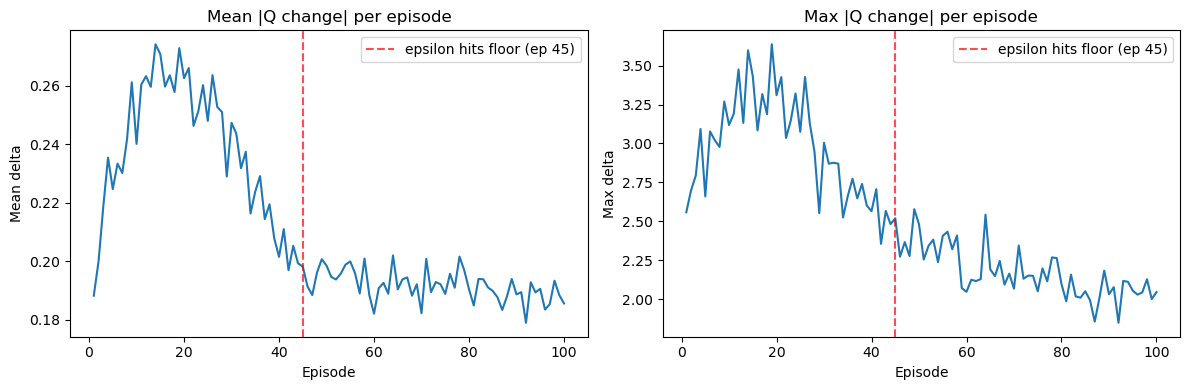


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.8%  min: 38.0%  max: 100.0%



In [41]:
from diagnostics import run_full_diagnostics

run_full_diagnostics(
    visit_counts=avg_visit_counts,
    delta_history=avg_delta_history_max,
    delta_history_mean=avg_delta_history_mean,
    seed_agents=seed_agents,
    greedy_actions=all_test_actions,
    n_actions=n_actions,
    epsilon_start=epsilon_start,
    epsilon_decay=epsilon_decay,
    epsilon_floor=epsilon_floor,
    train_results = train_results,
    test_results = test_results
)

Hyperparameter choosing. 

Here Hyperparameters are adjusted for the Q-learning model by considering convergence alongside the validation values outputed by the model.

In [42]:
# further split train_raw into an inner train/validation split, so hyperparameters
# are chosen without the search ever seeing the true held-out test_raw
hp_split = int(0.8 * len(train_raw))
hp_train_raw = train_raw[:hp_split]
hp_val_raw = train_raw[hp_split:]

print(f"Hyperparameter tuning -- inner train: {len(hp_train_raw)} days, inner validation: {len(hp_val_raw)} days")

Hyperparameter tuning -- inner train: 805 days, inner validation: 202 days


In [43]:
def grid_search_hyperparameters(train_fn, eta_grid, gamma_grid, N=20, episodes=episodes,
                                  epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                                  run_diagnostics=False):
    """Train N seeds per (eta, gamma) combination on hp_train_raw, score them on
    hp_val_raw (a held-out slice of the TRAINING data, not the true test set), and
    return a table of validation mean/std for every combination, best first.
    train_fn: one of train_and_evaluate_greedy / _expected_sarsa / _double_q --
    they all share the same (seed, train_raw, test_raw, ...) calling convention.
    episodes/epsilon_start/epsilon_decay/epsilon_floor default to the notebook's
    global values but can be overridden here without touching those globals (e.g.
    for a one-off test with a faster epsilon decay, a floor so epsilon never fully
    vanishes, or a different episode count).
    run_diagnostics: if True, also runs the full diagnostic checklist for every
    (eta, gamma) combination as it's evaluated - not just the eventual winner.
    Off by default since it multiplies the printed output by len(eta_grid)*len(gamma_grid).
    """
    rows = []
    for eta_try in eta_grid:
        for gamma_try in gamma_grid:
            val_scores = np.zeros(N)
            seed_agents = []
            all_delta_history_max = []
            all_delta_history_mean = []
            all_val_actions = []
            for seed in range(N):
                agent, _, val_final, delta_history_max, delta_history_mean, _, val_actions = train_fn(
                    seed, hp_train_raw, hp_val_raw, episodes=episodes,
                    n_bins=n_bins, n_actions=n_actions, eta=eta_try, gamma=gamma_try,
                    epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
                    bin_range=bin_range, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
                val_scores[seed] = val_final
                seed_agents.append(agent)
                all_delta_history_max.append(delta_history_max)
                all_delta_history_mean.append(delta_history_mean)
                all_val_actions.append(val_actions)
            rows.append({"eta": eta_try, "gamma": gamma_try,
                         "val_mean": val_scores.mean(), "val_std": val_scores.std()})

            if run_diagnostics:
                print(f"\n--- eta={eta_try}, gamma={gamma_try} ---")
                run_full_diagnostics(
                    visit_counts=np.mean([a.visit_counts for a in seed_agents], axis=0),
                    delta_history=np.mean(all_delta_history_max, axis=0),
                    delta_history_mean=np.mean(all_delta_history_mean, axis=0),
                    seed_agents=seed_agents,
                    greedy_actions=all_val_actions,
                    n_actions=n_actions,
                    epsilon_start=epsilon_start,
                    epsilon_decay=epsilon_decay,
                    epsilon_floor=epsilon_floor,
                )
    return pd.DataFrame(rows).sort_values("val_mean", ascending=False).reset_index(drop=True)



Choose small eta and relatively large gamma to see what leads to best convergence, more so then what leads to good results?

In [44]:
#eta_grid = [0.001, 0.005]
#gamma_grid = [0.95]
eta_grid = [0.001, 0.005, 0.01]
gamma_grid = [0.95, 0.99, 0.995]

In [45]:
# hyperparameters for the basic single-stock Q-learning agent
# (previously left over from a deleted cell's kernel state - now defined explicitly so this notebook reruns standalone)
n_bins = 10
n_actions = 3
#eta = 0.01
#gamma = 0.95
epsilon_start = 1.0
epsilon_decay = 0.95
epsilon_floor = 0.1
episodes = 80
N = 20
initial_cash = 10000
bin_range = (0.9, 1.1)  # daily price-return bins (price[t]/price[t-1]): 0.9-1.1 = -10% to +10%
n_cash_bins = 2
cash_bin_range = (0, 1)  # cash as a fraction of the CURRENT portfolio value: always exactly ~0 (invested)
                          # or exactly 1.0 (in cash) given the all-or-nothing buy/sell design, so this is
                          # a genuine binary position flag - a single edge at the midpoint (0.5) splits it


--- eta=0.001, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



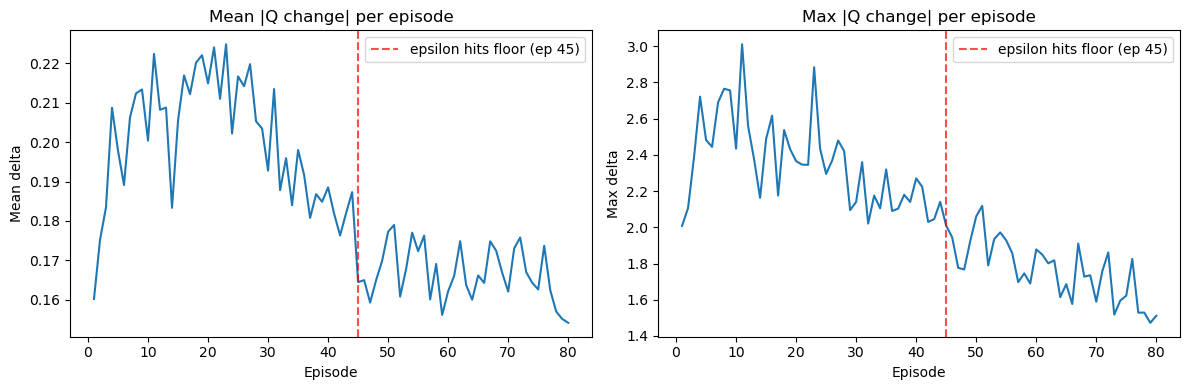


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 69.6%  min: 40.0%  max: 100.0%


--- eta=0.001, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



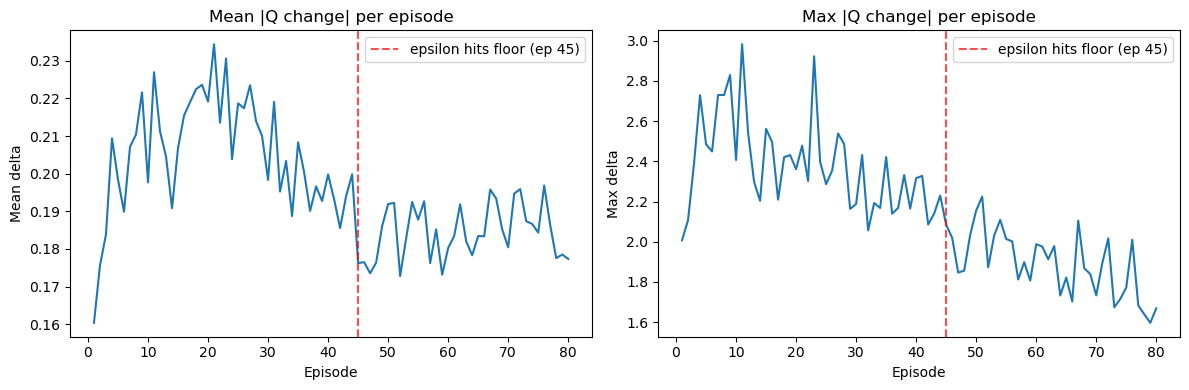


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.4%  min: 40.0%  max: 100.0%


--- eta=0.001, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



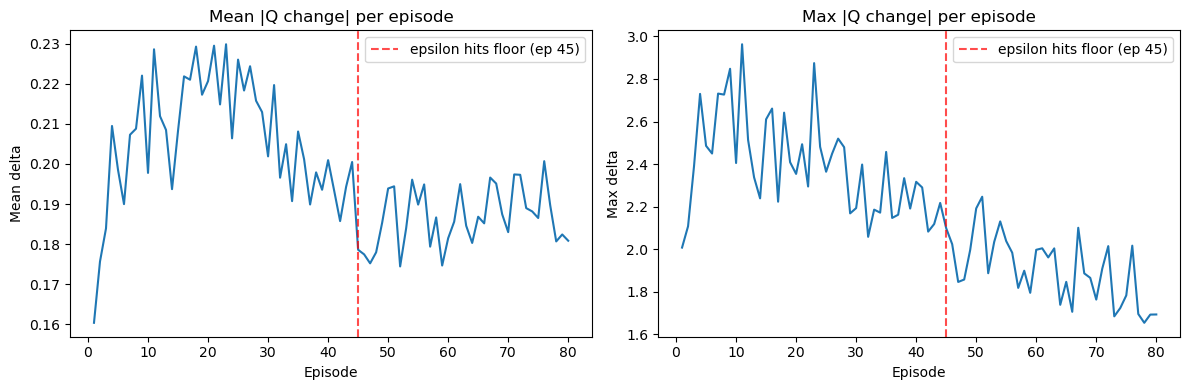


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 70.0%  min: 45.0%  max: 100.0%


--- eta=0.005, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



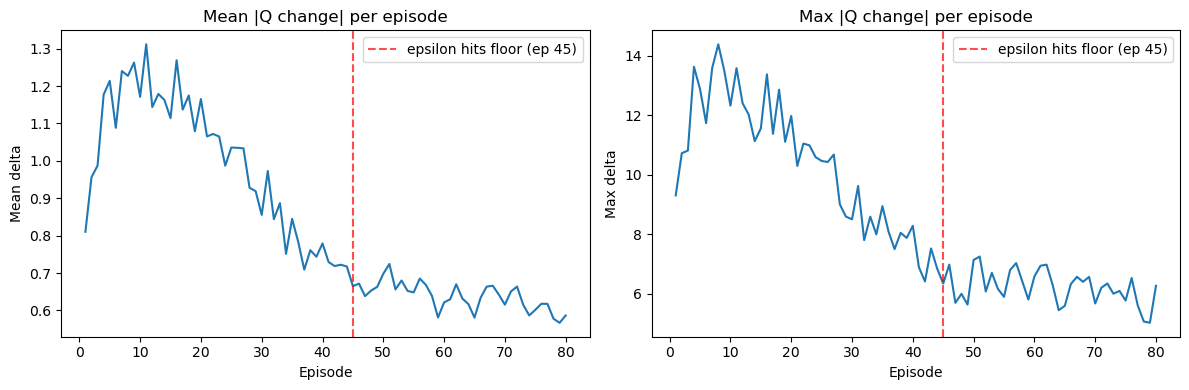


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 69.6%  min: 40.0%  max: 100.0%


--- eta=0.005, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



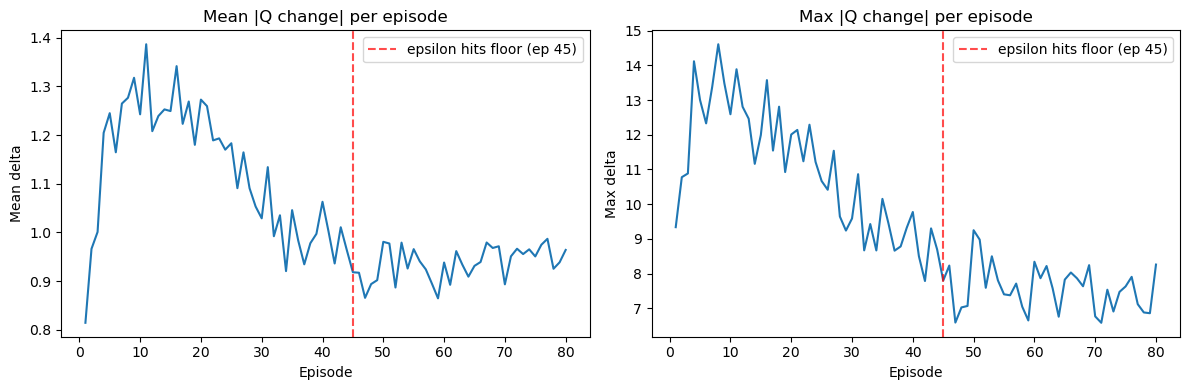


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.1%  min: 35.0%  max: 100.0%


--- eta=0.005, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



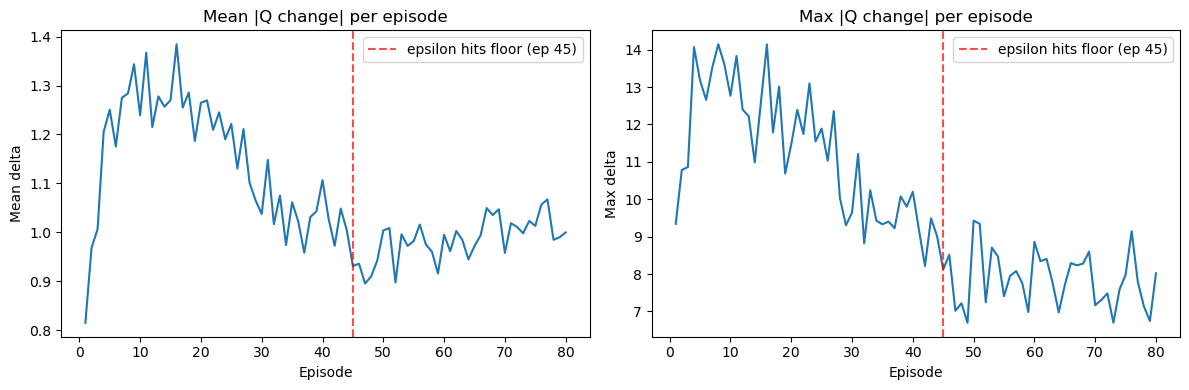


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 64.6%  min: 40.0%  max: 100.0%


--- eta=0.01, gamma=0.95 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



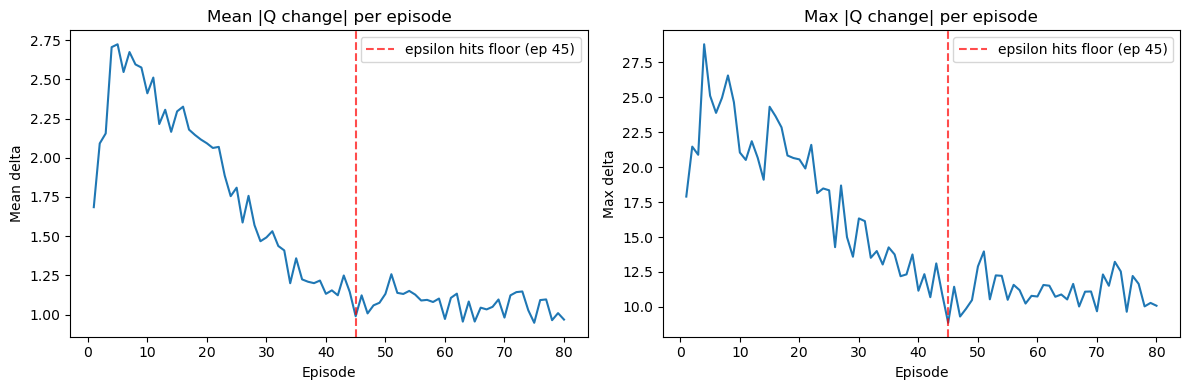


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.1%  min: 40.0%  max: 100.0%


--- eta=0.01, gamma=0.99 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



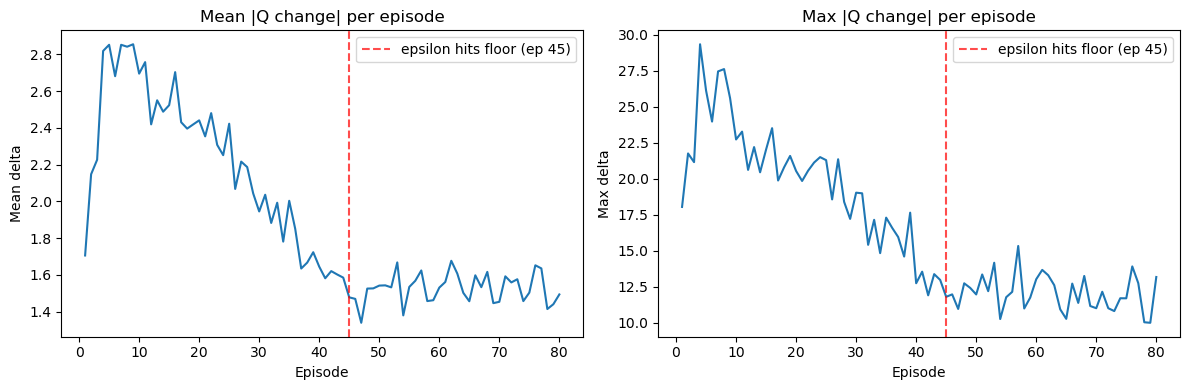


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.1%  min: 45.0%  max: 100.0%


--- eta=0.01, gamma=0.995 ---
DIAGNOSTIC CHECKLIST
[Train/Test] SKIPPED -- pass train_results and test_results to enable

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



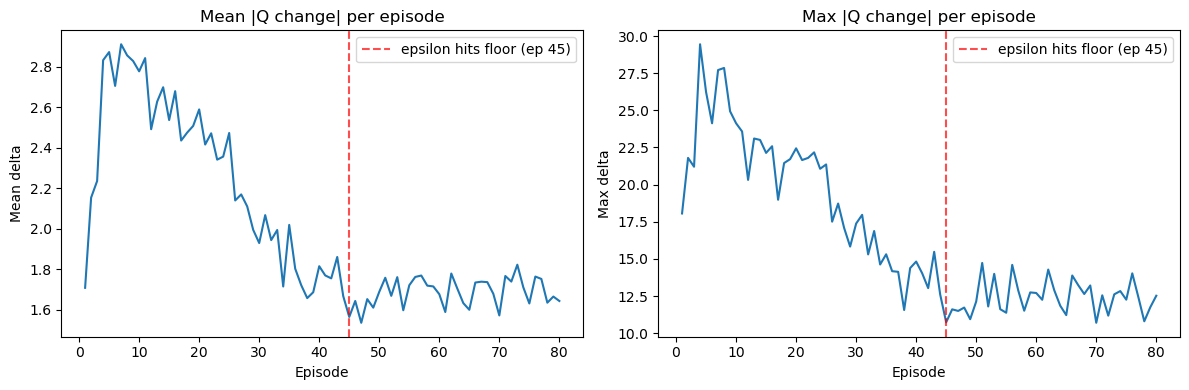


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 65.8%  min: 45.0%  max: 100.0%

Q-learning -- best (eta, gamma): (0.001, 0.995)


,eta,gamma,val_mean,val_std
0,0.001,0.995,11719.355,571.884509
1,0.005,0.995,11705.591,1138.688901
2,0.001,0.950,11697.758,590.521907
3,0.001,0.990,11693.311,592.237110
4,0.005,0.990,11587.123,1119.921713
5,0.005,0.950,10833.372,1119.661766
6,0.010,0.995,10480.657,1210.477573
7,0.010,0.990,10402.062,1168.468660
8,0.010,0.950,10067.837,779.204227


In [46]:
q_learning_search = grid_search_hyperparameters(train_and_evaluate_greedy, eta_grid, gamma_grid, N=20, episodes=episodes,
                                  epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor, run_diagnostics=True)
print("Q-learning -- best (eta, gamma):", tuple(q_learning_search.iloc[0][["eta", "gamma"]]))
q_learning_search

In [24]:
def evaluate_best_hyperparameters(train_fn, eta_best, gamma_best, N=50, episodes=episodes,
                                    epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=0.0):
    """Retrain N seeds on the FULL train_raw with the given (eta, gamma), evaluate on
    the true held-out test_raw, and return everything needed both for the comparison
    table and for running full diagnostics on this tuned run.
    episodes/epsilon_start/epsilon_decay/epsilon_floor default to the notebook's
    global values but can be overridden here without touching those globals."""
    train_vals = np.zeros(N)
    test_vals = np.zeros(N)
    seed_agents = []
    all_delta_history_max = []
    all_delta_history_mean = []
    all_test_actions = []

    for seed in range(N):
        agent, train_final, test_final, delta_history_max, delta_history_mean, train_actions, test_actions = train_fn(
            seed, train_raw, test_raw, episodes=episodes,
            n_bins=n_bins, n_actions=n_actions, eta=eta_best, gamma=gamma_best,
            epsilon_start=epsilon_start, epsilon_decay=epsilon_decay, epsilon_floor=epsilon_floor,
            bin_range=bin_range, n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
        train_vals[seed] = train_final
        test_vals[seed] = test_final
        seed_agents.append(agent)
        all_delta_history_max.append(delta_history_max)
        all_delta_history_mean.append(delta_history_mean)
        all_test_actions.append(test_actions)

    return {
        "train_results": train_vals,
        "test_results": test_vals,
        "seed_agents": seed_agents,
        "avg_delta_history_max": np.mean(all_delta_history_max, axis=0),
        "avg_delta_history_mean": np.mean(all_delta_history_mean, axis=0),
        "avg_visit_counts": np.mean([agent.visit_counts for agent in seed_agents], axis=0),
        "all_test_actions": all_test_actions,
    }

Generally the best eta_q and gamma_q are based on the validation values though this changes depending on the situation.

In [26]:
best_eta_q, best_gamma_q = q_learning_search.iloc[0][["eta", "gamma"]]
best_q = evaluate_best_hyperparameters(train_and_evaluate_greedy, best_eta_q, best_gamma_q)


DIAGNOSTIC CHECKLIST
[Train/Test] Train -- mean: 11883.33  std: 138.33
[Train/Test] Test  -- mean: 11466.19  std: 872.52

[Coverage] Unvisited (state, action) pairs: 12 / 60 (20.0%)
  Unvisited pairs (state..., action): [(np.int64(0), np.int64(0), np.int64(0)), (np.int64(0), np.int64(0), np.int64(1)), (np.int64(0), np.int64(0), np.int64(2)), (np.int64(0), np.int64(1), np.int64(0)), (np.int64(0), np.int64(1), np.int64(1)), (np.int64(0), np.int64(1), np.int64(2)), (np.int64(9), np.int64(0), np.int64(0)), (np.int64(9), np.int64(0), np.int64(1)), (np.int64(9), np.int64(0), np.int64(2)), (np.int64(9), np.int64(1), np.int64(0))] ...



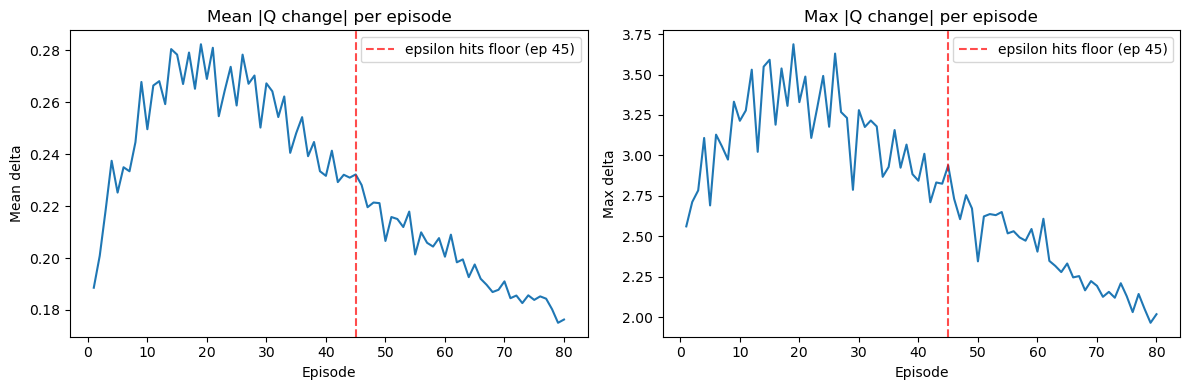


[Policy stability] States checked: 12/20 total states in the state space had >= 100 average visits across seeds
[Policy stability] Per-state majority agreement, across those 12 states -- mean: 67.3%  min: 42.0%  max: 100.0%



In [27]:
run_full_diagnostics(
    visit_counts=best_q["avg_visit_counts"],
    delta_history=best_q["avg_delta_history_max"],
    delta_history_mean=best_q["avg_delta_history_mean"],
    seed_agents=best_q["seed_agents"],
    greedy_actions=best_q["all_test_actions"],
    n_actions=n_actions,
    epsilon_start = epsilon_start,
    epsilon_decay = epsilon_decay,
    epsilon_floor = epsilon_floor,
    train_results = best_q["train_results"],
    test_results = best_q["test_results"]
)

The train standard deviation is a lot less than the test standard deviation. This might have more to do with the nature of the stock that the particulars of the model being run, the plot below show sthat

An actual plot of the stock to see if it makes sense.

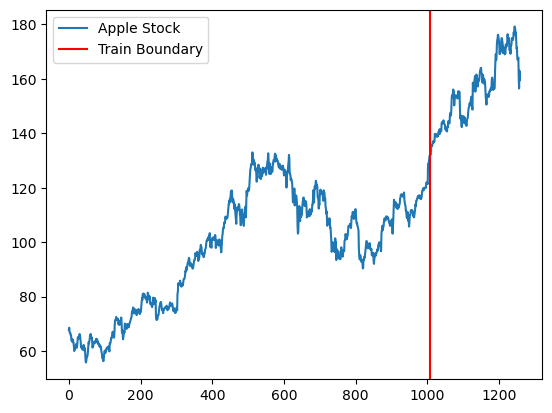

In [28]:
plt.plot(stock_data[:,0], label='Apple Stock')
plt.axvline(split, color='r', label='Train Boundary')
plt.legend()

## Comparison with Other Strategies

### Random Trading

In [19]:
def run_random(raw, n_bins, n_actions, seed):
    rng = np.random.default_rng(seed)
    state = State_basic(raw, initial_cash, n_bins=n_bins, bin_range=bin_range,
                         n_cash_bins=n_cash_bins, cash_bin_range=cash_bin_range)
    for t in range(len(raw) - 1):
        a = rng.integers(0, n_actions)
        state.reward(a, t)
    final_value = state.portfolio_value(len(raw) - 1)
    return annualization(final_value, len(raw) - 1, initial_cash)

# average over multiple seeds, since a single random run is noisy
random_train_results = np.array([run_random(train_raw, n_bins, n_actions, seed) for seed in range(N)])
random_test_results = np.array([run_random(test_raw, n_bins, n_actions, seed) for seed in range(N)])

print(f"Random trading -- Train: mean={random_train_results.mean():.2f}, std={random_train_results.std():.2f}")
print(f"Random trading -- Test:  mean={random_test_results.mean():.2f}, std={random_test_results.std():.2f}")

Random trading -- Train: mean=10968.81, std=640.32
Random trading -- Test:  mean=11402.36, std=1032.82


### Buy and Hold Strategy

In [23]:
def run_buy_and_hold(raw, initial_cash):
    shares = int(initial_cash / raw[0])
    cash = initial_cash - shares * raw[0]
    final_value = cash + shares * raw[-1]
    return annualization(final_value, len(raw) - 1, initial_cash)

buy_hold_train = run_buy_and_hold(train_raw, initial_cash)
buy_hold_test = run_buy_and_hold(test_raw, initial_cash)

print(f"Buy & hold -- Train: {buy_hold_train:.2f}   Test: {buy_hold_test:.2f}")

Buy & hold -- Train: 11799.70   Test: 12071.51
